1. Wybierz dowolny zbiór danych z UCI Machine Learning Repository lub Kaggle Datasets, który spełnia następujące kryteria:

zawiera co najmniej 150 obserwacji,
posiada przynajmniej 3 zmienne numeryczne,
zawiera zmienną kategoryczną jako etykietę klasyfikacyjną.
Uwaga: Każda para wybiera inny zbiór danych!

In [55]:
import pandas as pd
import os
import kagglehub
from sklearn.ensemble import GradientBoostingClassifier

# 1. Pobieranie ścieżki
path = kagglehub.dataset_download("uom190346a/water-quality-and-potability")

# 2. Listowanie plików w pobranym folderze, aby sprawdzić co tam jest
files = os.listdir(path)
print(f"Pliki w folderze: {files}")

# 3. Znalezienie pliku CSV (zazwyczaj nazywa się 'water_potability.csv')
csv_filename = [f for f in files if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_filename)

print(f"Próba otwarcia pliku: {full_path}")

# 4. Wczytanie właściwego pliku
df = pd.read_csv(full_path)
df['Potability'] = df['Potability'].astype('category')

n_rows, n_cols = df.shape
n_numeric = df.select_dtypes(include=['number']).shape[1]
n_categorical = df.select_dtypes(include=['object', 'category']).shape[1]

print(f"Liczba obserwacji: {n_rows}")
print(f"Liczba zmiennych (wszystkich): {n_cols}")
print(f"Liczba zmiennych numerycznych: {n_numeric}")
print(f"Liczba zmiennych kategorycznych: {n_categorical}")

Pliki w folderze: ['water_potability.csv']
Próba otwarcia pliku: C:\Users\megaz\.cache\kagglehub\datasets\uom190346a\water-quality-and-potability\versions\2\water_potability.csv
Liczba obserwacji: 3276
Liczba zmiennych (wszystkich): 10
Liczba zmiennych numerycznych: 9
Liczba zmiennych kategorycznych: 1


2. Krótko opisz wybrany zbiór – źródło danych (link do repozytorium), czego dotyczą dane, liczba obserwacji i cech, charakterystyka atrybutu decyzyjnego (np. liczba klas, rodzaj wartości).

https://www.kaggle.com/datasets/uom190346a/water-quality-and-potability

Zbiór danych wykorzystany do projektu pochodzi z serwisu Kaggle. Zbiór danych zatytułowany Water Quality – Potabilit zawiera informacje dotyczące jakości wody oraz jej przydatności do spożycia przez ludzi. Celem zbioru danych jest umożliwienie analizy parametrów jakości wody w kontekście oceny jej zdatności do picia. Każdy rekord w zbiorze reprezentuje pojedynczą próbkę wody, opisaną za pomocą dziewięciu atrybutów pomiarowych. Ostatnia kolumna Potability jest atrybutem decyzyjnym w tym zbiorze i wskazuje, czy dana próbka jest uznana za zdatną do spożycia (wartość 1), czy też nie (wartość 0) i to ten atrybut będzie klasyfikacjynym.
Opis pozostałych atrybutów:
* pH – poziom pH wody; miernik kwasowości lub zasadowości cieczy.
* Hardness – twardość wody, czyli stężenie jonów wapnia i magnezu.
* Solids – całkowita ilość rozpuszczonych substancji stałych.
* Chloramines – stężenie chloramin w wodzie.
* Sulfate – stężenie siarczanów.
* Conductivity – przewodność elektryczna wody.
* Organic_carbon – zawartość węgla organicznego.
* Trihalomethanes – stężenie trójhalometanów.
* Turbidity – mętność wody.

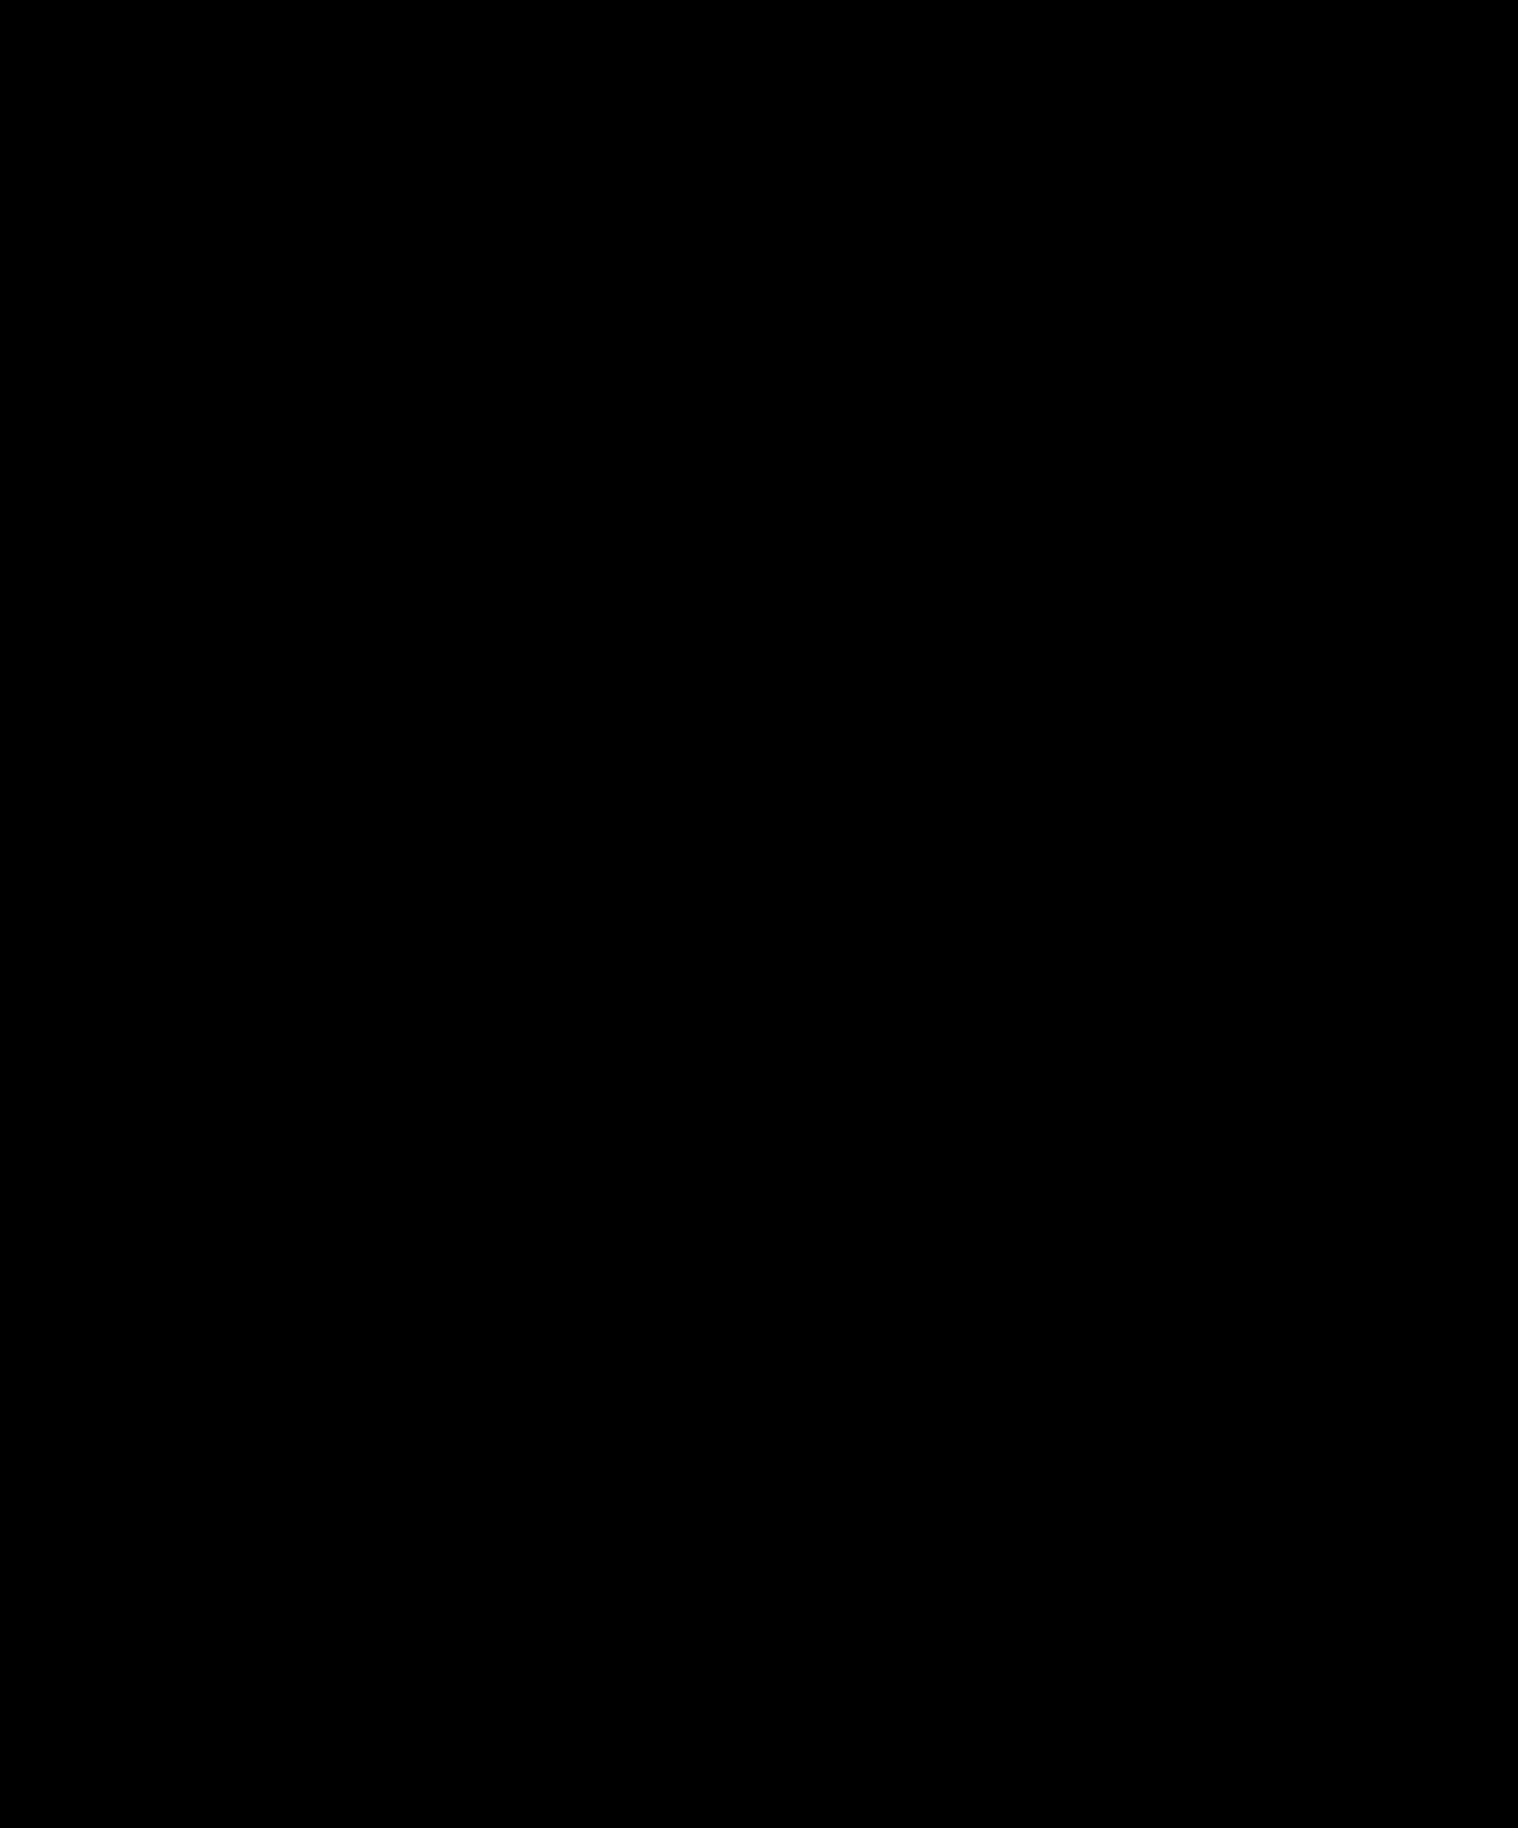
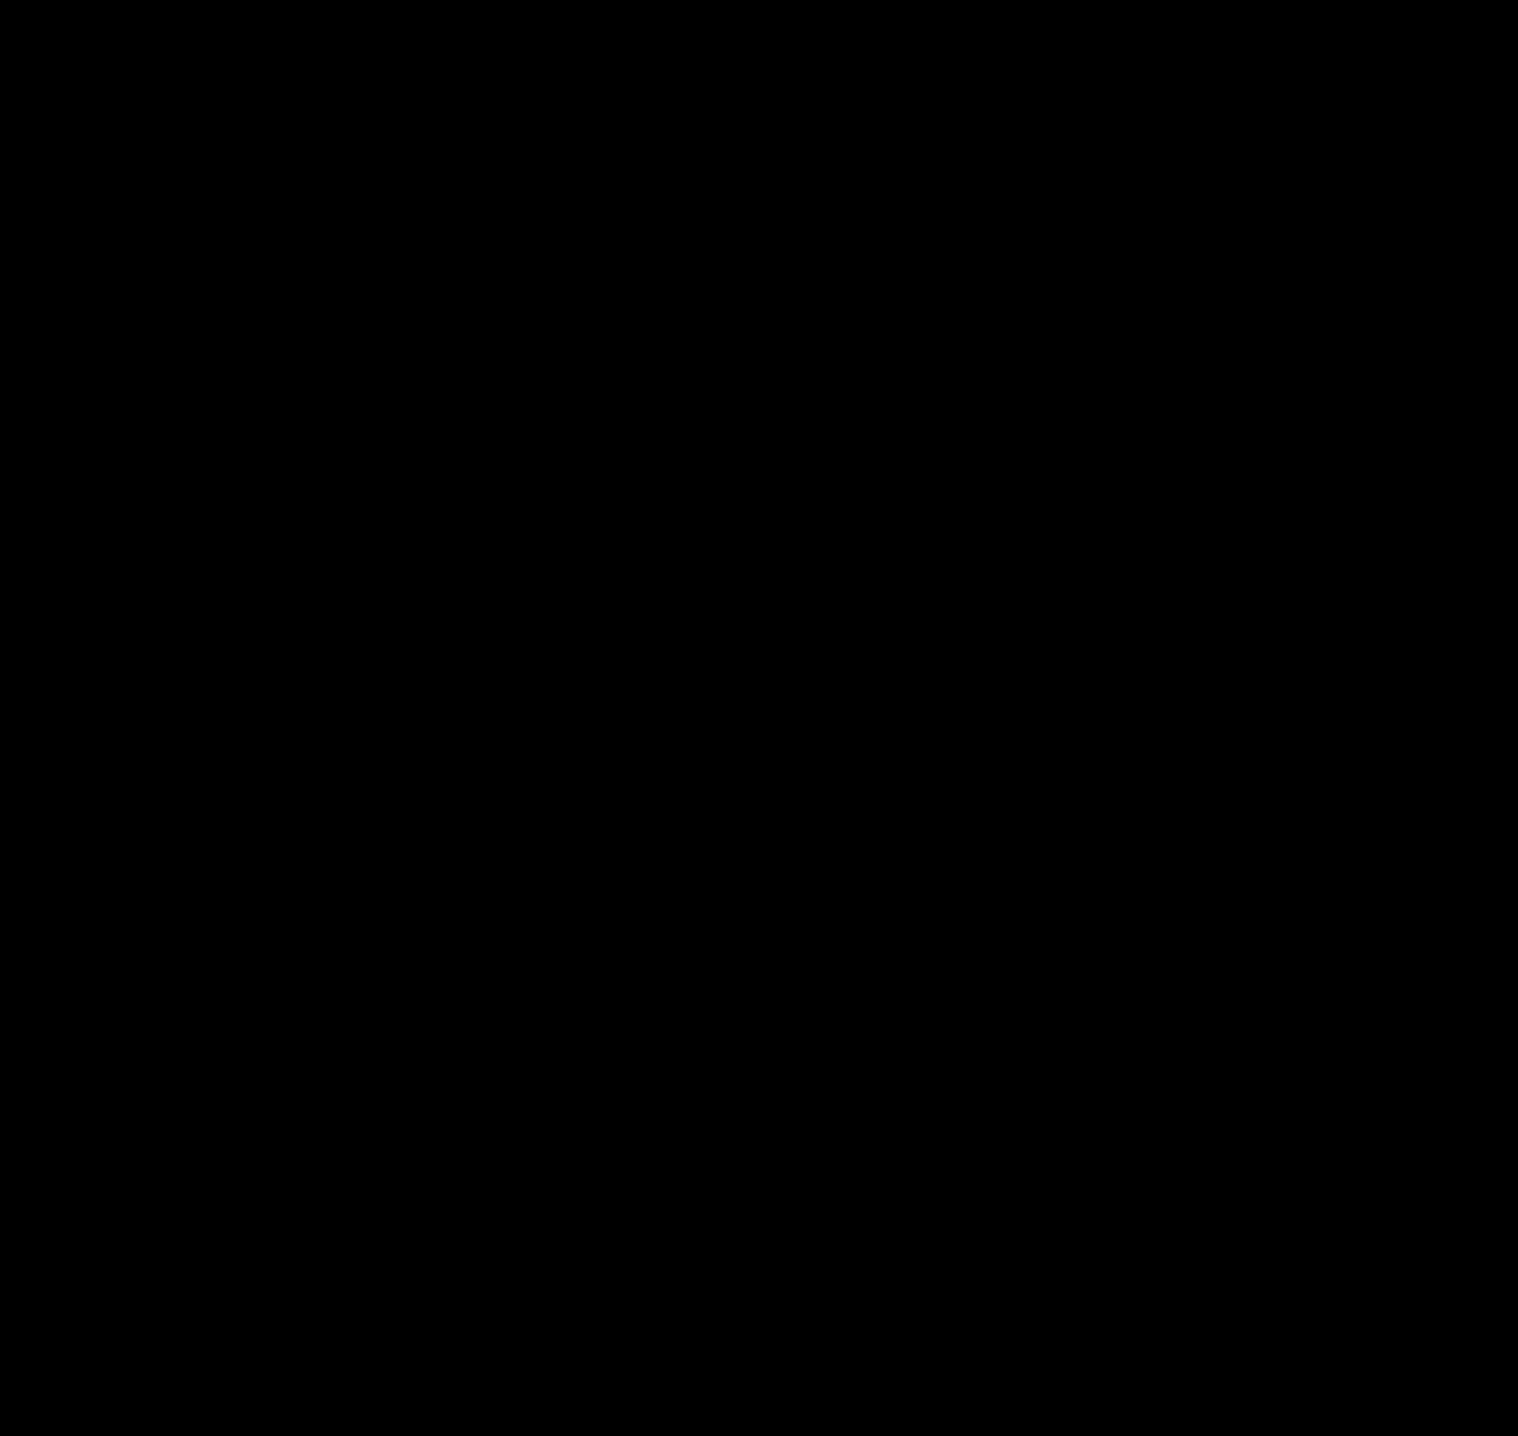
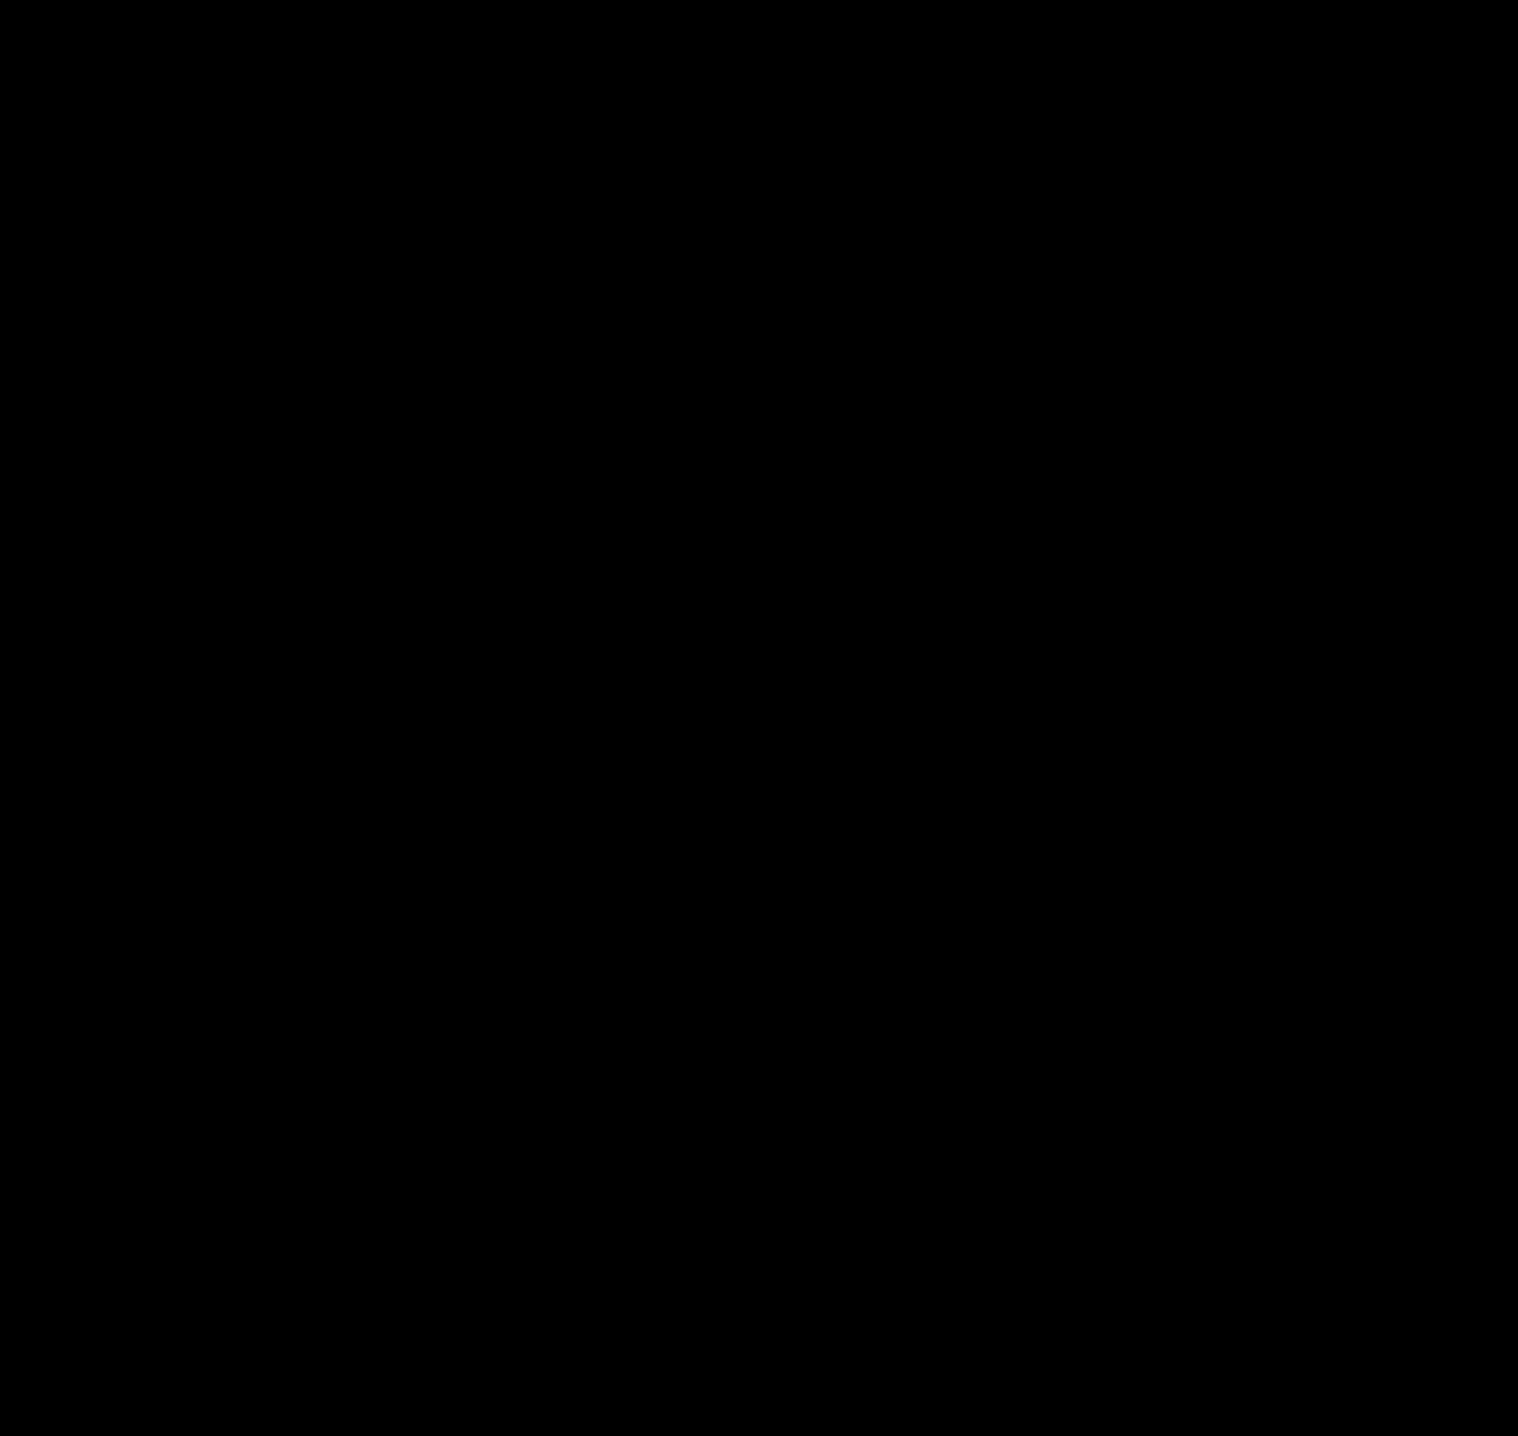

3. Przeprowadź preprocessing danych, obejmujący:

obsługę brakujących wartości,
kodowanie zmiennych kategorycznych,
podział zbioru danych na treningowy i testowy.
Każdy wykonany krok powinien być odpowiednio skomentowany.

In [56]:
from sklearn.model_selection import train_test_split

# Sprawdzenie liczby braków
print("Braki danych w kolumnach:")
print(df.isnull().sum())

# Uzupełnienie brakujących wartości medianą (dla danych numerycznych)
# Medianę stosujemy, bo jest odporna na wartości odstające
df = df.fillna(df.median(numeric_only=True))

# Sprawdzenie czy nadal są braki
print("\nBraki po uzupełnieniu:")
print(df.isnull().sum())

# Brak potrzeby kodowania zmiennych
print("\nZakodowane klasy:", df['Potability'].unique())

# Oddzielenie cech (X) i zmiennej docelowej (y)
X = df.drop('Potability', axis=1)
y = df['Potability']

# Podział danych:
# 20% danych na test
# random_state zapewnia powtarzalność wyników
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # zachowanie proporcji klas
)


Braki danych w kolumnach:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Braki po uzupełnieniu:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Zakodowane klasy: [0, 1]
Categories (2, int64): [0, 1]


4. Dokonaj implementacji omówionych na zajęciach metod zespołowych:

Bagging:
Zastosuj Random Forest.
Dobierz hiperparametry (n_estimators, max_depth).
Dokonaj predykcji i oblicz dokładność klasyfikacji modelu.
Skomentuj wyniki modelu.
Boosting:
Wybierz jeden z algorytmów boostingu (AdaBoost, Gradient Boosting, XGBoost).
Przeprowadź strojenie hiperparametrów, testując n_estimators, learning_rate i max_depth.
Oblicz dokładność klasyfikacji modelu.
Skomentuj wyniki modelu.
Stacking:
Wybierz co najmniej dwa modele bazowe, np. drzewo decyzyjne, SVM, regresję logistyczną.
Jako meta-model zastosuj np. regresję logistyczną.
Połącz modele za pomocą StackingClassifier.
Oblicz dokładność klasyfikacji modelu.
Skomentuj wyniki modelu.
5. Porównaj skuteczność wszystkich trzech metod:

Która metoda osiągnęła najwyższą dokładność?
Czy stacking poprawił wyniki względem pojedynczych modeli?
Jakie są wnioski z eksperymentu?

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_results = []

for n in [50, 100, 200]:
    for depth in [3, 5, 10]:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)

        rf_results.append((n, depth, acc))

# Najlepszy wynik
best_rf = max(rf_results, key=lambda x: x[2])
print("Najlepszy Random Forest:", best_rf)



Najlepszy Random Forest: (100, 10, 0.6692073170731707)


In [58]:
from sklearn.ensemble import GradientBoostingClassifier

gb_results = []

for n in [50, 100, 200]:
    for lr in [0.01, 0.1, 0.2]:
        for depth in [2, 3, 4]:
            gb = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=depth,
                random_state=42
            )
            gb.fit(X_train, y_train)
            y_pred = gb.predict(X_test)
            acc = accuracy_score(y_test, y_pred)

            gb_results.append((n, lr, depth, acc))

best_gb = max(gb_results, key=lambda x: x[3])
print("Najlepszy Gradient Boosting:", best_gb)

Najlepszy Gradient Boosting: (200, 0.1, 3, 0.663109756097561)


In [59]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

# Modele bazowe
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=100)),
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression(max_iter=10000)),
]

# Meta-model
meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model
)

stack.fit(X_train, y_train)
y_pred_stack = stack.predict(X_test)

acc_stack = accuracy_score(y_test, y_pred_stack)

print("Stacking accuracy:", acc_stack)

Stacking accuracy: 0.6097560975609756


In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),

    ('svm', Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, C=1))
    ])),

    ('knn', Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ]))
]

meta_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)

stack = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True
)

# Trenowanie
stack.fit(X_train, y_train)

# Predykcja
y_pred_stack = stack.predict(X_test)

# Wynik
acc_stack_new = accuracy_score(y_test, y_pred_stack)

print("Nowy Stacking accuracy:", acc_stack_new)

Nowy Stacking accuracy: 0.6722560975609756


In [71]:
print("\n=== PODSUMOWANIE ===")
print(f"Random Forest:      {best_rf[2]*100:.2f}%")
print(f"Gradient Boosting:  {best_gb[3]*100:.2f}%")
print(f"Stacking:           {acc_stack*100:.2f}%")
print(f"Stacking new:           {acc_stack_new*100:.2f}%")


=== PODSUMOWANIE ===
Random Forest:      66.92%
Gradient Boosting:  66.31%
Stacking:           60.98%
Stacking new:           67.23%


W przeprowadzonym eksperymencie porównano trzy metody zespołowe: bagging (Random Forest), boosting (Gradient Boosting) oraz stacking.

Najwyższą skuteczność uzyskał model stacking po optymalizacji parametrów, osiągając dokładność na poziomie 67.23%. Początkowa implementacja stackingu dawała znacznie gorsze wyniki (60.98%), jednak po zastosowaniu odpowiednich usprawnień, takich jak dobór bardziej zróżnicowanych modeli bazowych, skalowanie danych, zastosowanie walidacji krzyżowej oraz wykorzystanie modelu Gradient Boosting jako meta-modelu, uzyskano znaczną poprawę jakości klasyfikacji.

Modele Random Forest oraz Gradient Boosting osiągnęły zbliżone wyniki (około 66–67%), co potwierdza ich wysoką skuteczność w zadaniach klasyfikacyjnych.

Wyniki wskazują, że stacking może przewyższać inne metody zespołowe, jednak wymaga odpowiedniego dostrojenia. Bez optymalizacji może prowadzić do gorszych rezultatów niż pojedyncze modele.